# Notebook 08 - Calibration Analysis

Calibration diagnostics for the PCOS screening and enhanced models. Clinicians act on probabilities, so the probabilities must reflect actual event rates. This notebook reports the raw Brier score and Expected Calibration Error (ECE), fits Platt (sigmoid) and isotonic recalibrators on a held-out slice of the training set, and produces reliability diagrams with 95% Wilson confidence intervals.

Reference: Van Calster et al., *BMC Medicine* 2019 - calibration is essential when predictions inform clinical decisions.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from packaging.version import Version
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "outputs" / "pcos_cleaned.csv"
MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
METRIC_DIR = PROJECT_ROOT / "outputs" / "metrics"
for folder in (FIGURE_DIR, METRIC_DIR):
    folder.mkdir(parents=True, exist_ok=True)

SKLEARN_VERSION = Version(sklearn.__version__)
USE_FROZEN = SKLEARN_VERSION >= Version("1.6")
print("sklearn:", sklearn.__version__, "| FrozenEstimator path:", USE_FROZEN)

sklearn: 1.6.1 | FrozenEstimator path: True


## Helpers

- `wrap_prefit` returns a `CalibratedClassifierCV` that wraps an already-fitted pipeline using `FrozenEstimator` on sklearn >= 1.6 and the legacy `cv="prefit"` path otherwise.
- `expected_calibration_error` computes the standard equal-width ECE used in the calibration literature (Naeini 2015; Guo et al. 2017).
- `wilson_interval` produces 95% binomial CIs that remain well-defined when a bin has zero events.

In [2]:
def wrap_prefit(fitted_estimator, method: str) -> CalibratedClassifierCV:
    """Wrap a fitted estimator for post-hoc calibration in a version-safe way."""
    if USE_FROZEN:
        from sklearn.frozen import FrozenEstimator
        return CalibratedClassifierCV(FrozenEstimator(fitted_estimator), method=method, cv=None)
    return CalibratedClassifierCV(fitted_estimator, method=method, cv="prefit")


def wilson_interval(successes: int, trials: int, z: float = 1.96):
    if trials == 0:
        return (np.nan, np.nan)
    p_hat = successes / trials
    denom = 1.0 + z**2 / trials
    centre = (p_hat + z**2 / (2 * trials)) / denom
    half = (z * np.sqrt(p_hat * (1 - p_hat) / trials + z**2 / (4 * trials**2))) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def bin_reliability(y_true, y_prob, n_bins: int = 10) -> pd.DataFrame:
    """Per-bin reliability stats (mean predicted, empirical rate, Wilson CIs, count)."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_prob, bins[1:-1])
    rows = []
    for b in range(n_bins):
        mask = idx == b
        if not mask.any():
            continue
        succ = int(y_true[mask].sum())
        n = int(mask.sum())
        lo, hi = wilson_interval(succ, n)
        rows.append({
            "bin_lo": bins[b],
            "bin_hi": bins[b + 1],
            "mean_pred": float(y_prob[mask].mean()),
            "frac_pos": succ / n,
            "ci_lo": lo,
            "ci_hi": hi,
            "count": n,
        })
    return pd.DataFrame(rows)


def expected_calibration_error_from_bins(rel: pd.DataFrame, n_total: int) -> float:
    if rel.empty or n_total == 0:
        return 0.0
    weights = rel["count"].to_numpy() / n_total
    gaps = (rel["mean_pred"] - rel["frac_pos"]).abs().to_numpy()
    return float((weights * gaps).sum())


## Load data and refit calibrators per model

For each model artifact we:
1. Reproduce the train/test split (`test_size=0.25`, `stratify=y`, `random_state=42`).
2. Carve a 30% calibration slice from the *training* set (the holdout test set is never touched).
3. Refit the saved pipeline on the remaining 70% to keep the recalibrator from seeing the same rows the base learner saw.
4. Wrap that pipeline with Platt (sigmoid) and isotonic recalibrators fitted on the calibration slice.
5. Score raw / Platt / isotonic probabilities on the held-out test set.

In [3]:
df = pd.read_csv(DATA_PATH)
TARGET = "pcos_y_n"
print("Rows:", len(df), "| target balance:", df[TARGET].value_counts().to_dict())

MODEL_SPECS = {
    "screening": MODEL_DIR / "pcos_screening_model.joblib",
    "enhanced": MODEL_DIR / "pcos_enhanced_model.joblib",
}
artifacts = {name: joblib.load(p) for name, p in MODEL_SPECS.items()}
for name, art in artifacts.items():
    print(f"{name}: features={len(art['features'])}, threshold={art['threshold']}")

Rows: 541 | target balance: {0: 364, 1: 177}


screening: features=13, threshold=0.285
enhanced: features=27, threshold=0.38


In [4]:
from sklearn.base import clone

def prepare_calibration(artifact: dict, df: pd.DataFrame, target: str = TARGET):
    features = artifact["features"]
    base_pipeline = artifact["model"]
    X = df[features].copy()
    y = df[target].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    X_fit, X_cal, y_fit, y_cal = train_test_split(
        X_train, y_train, test_size=0.30, stratify=y_train, random_state=RANDOM_STATE
    )

    refit_pipeline = clone(base_pipeline)
    refit_pipeline.fit(X_fit, y_fit)

    platt = wrap_prefit(refit_pipeline, method="sigmoid").fit(X_cal, y_cal)
    isotonic = wrap_prefit(refit_pipeline, method="isotonic").fit(X_cal, y_cal)

    probs = {
        "raw": refit_pipeline.predict_proba(X_test)[:, 1],
        "platt": platt.predict_proba(X_test)[:, 1],
        "isotonic": isotonic.predict_proba(X_test)[:, 1],
    }
    return {
        "y_test": y_test.to_numpy(),
        "probs": probs,
        "n_calibration": int(len(X_cal)),
        "n_holdout": int(len(X_test)),
        "n_fit": int(len(X_fit)),
    }

results = {name: prepare_calibration(art, df) for name, art in artifacts.items()}
for name, r in results.items():
    print(f"{name}: n_fit={r['n_fit']} n_cal={r['n_calibration']} n_test={r['n_holdout']}")

screening: n_fit=283 n_cal=122 n_test=136
enhanced: n_fit=283 n_cal=122 n_test=136


## Metric table - Brier and ECE before/after recalibration

In [5]:
metrics: dict[str, dict] = {}
rows = []
bin_cache: dict[tuple[str, str], pd.DataFrame] = {}
for name, r in results.items():
    n_holdout = r["n_holdout"]
    entry = {"n_calibration": r["n_calibration"], "n_holdout": n_holdout}
    for variant, prob in r["probs"].items():
        rel = bin_reliability(r["y_test"], prob, n_bins=10)
        bin_cache[(name, variant)] = rel
        brier = float(brier_score_loss(r["y_test"], prob))
        ece = expected_calibration_error_from_bins(rel, n_holdout)
        entry[f"brier_{variant}"] = brier
        entry[f"ece_{variant}"] = ece
        rows.append({"model": name, "variant": variant, "brier": brier, "ece": ece})
    metrics[name] = entry

metric_df = pd.DataFrame(rows).set_index(["model", "variant"]).sort_index()
metric_df

brier       ece
model     variant                     
enhanced  isotonic  0.074424  0.047648
          platt     0.072109  0.044775
          raw       0.092888  0.142692
screening isotonic  0.124173  0.073191
          platt     0.116283  0.073049
          raw       0.127748  0.107020

## Reliability diagrams

Each curve plots empirical positive rate vs mean predicted probability per bin, with 95% Wilson CIs. Points on the diagonal indicate perfect calibration.

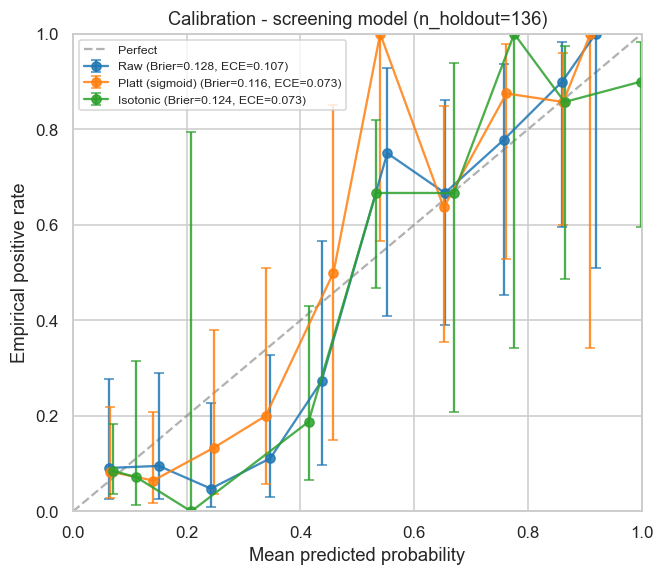

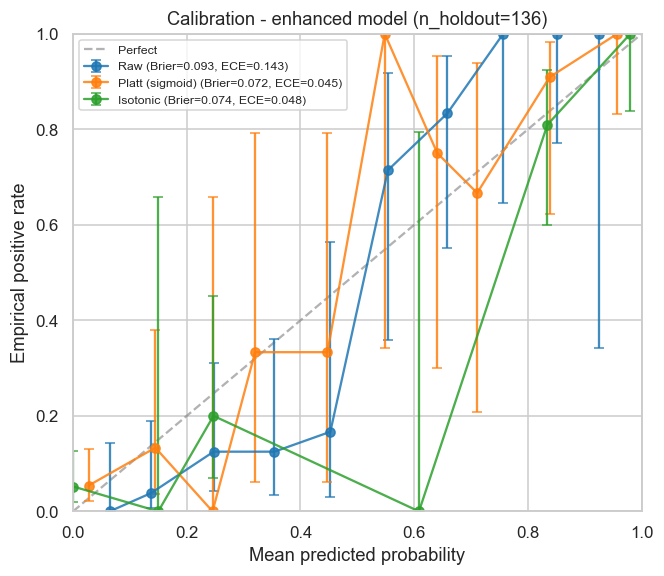

{'screening': 'C:\\Users\\kex03\\Downloads\\biohackathon\\.claude\\worktrees\\agent-ab13fbb603f123cf7\\outputs\\figures\\calibration_screening.png', 'enhanced': 'C:\\Users\\kex03\\Downloads\\biohackathon\\.claude\\worktrees\\agent-ab13fbb603f123cf7\\outputs\\figures\\calibration_enhanced.png'}


In [6]:
VARIANT_STYLE = {
    "raw": {"color": "#1f77b4", "label": "Raw"},
    "platt": {"color": "#ff7f0e", "label": "Platt (sigmoid)"},
    "isotonic": {"color": "#2ca02c", "label": "Isotonic"},
}


def plot_reliability(ax, model_name: str, probs: dict, title: str, model_metrics: dict):
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.6, label="Perfect")
    for variant in probs:
        style = VARIANT_STYLE[variant]
        rel = bin_cache[(model_name, variant)]
        if rel.empty:
            continue
        yerr = np.vstack([rel["frac_pos"] - rel["ci_lo"], rel["ci_hi"] - rel["frac_pos"]])
        ax.errorbar(
            rel["mean_pred"], rel["frac_pos"], yerr=yerr,
            fmt="o-", color=style["color"],
            label=f"{style['label']} (Brier={model_metrics['brier_' + variant]:.3f}, ECE={model_metrics['ece_' + variant]:.3f})",
            capsize=3, alpha=0.85,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Empirical positive rate")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)


figure_paths: dict[str, Path] = {}
for name, r in results.items():
    fig, ax = plt.subplots(figsize=(6.2, 5.4))
    plot_reliability(
        ax, name, r["probs"],
        title=f"Calibration - {name} model (n_holdout={r['n_holdout']})",
        model_metrics=metrics[name],
    )
    fig.tight_layout()
    out_path = FIGURE_DIR / f"calibration_{name}.png"
    fig.savefig(out_path)
    figure_paths[name] = out_path
    plt.show()
    plt.close(fig)

print({k: str(v) for k, v in figure_paths.items()})

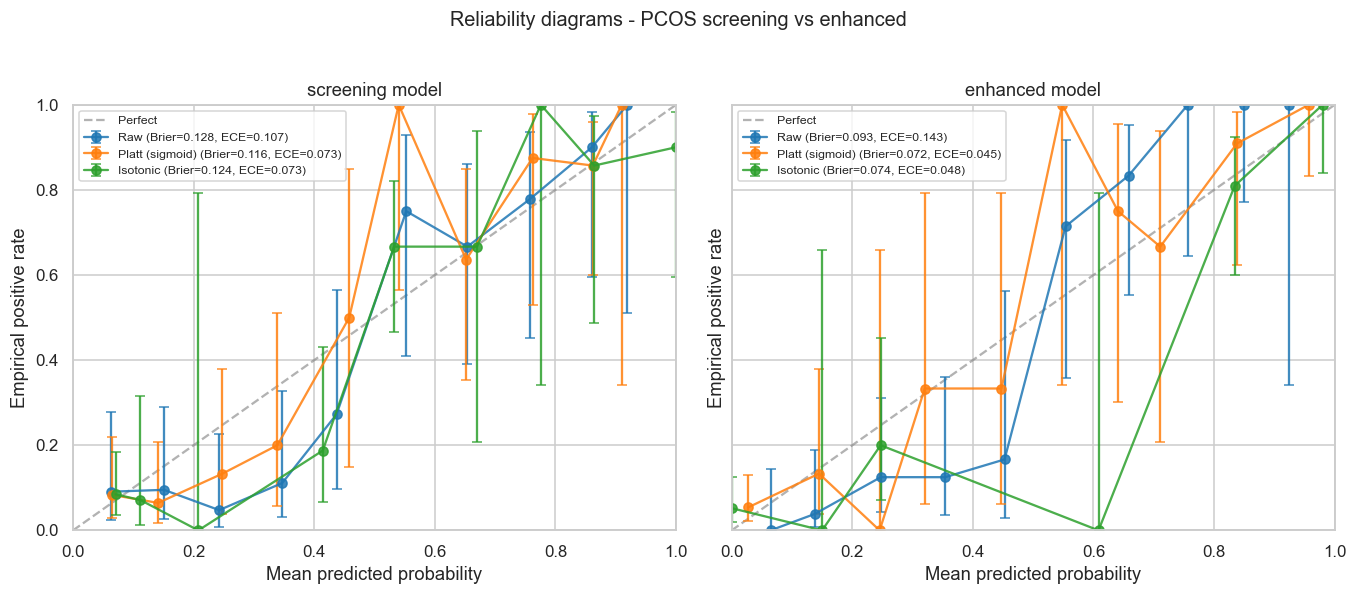

Saved: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ab13fbb603f123cf7\outputs\figures\calibration_combined.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5), sharey=True)
for ax, (name, r) in zip(axes, results.items()):
    plot_reliability(
        ax, name, r["probs"],
        title=f"{name} model",
        model_metrics=metrics[name],
    )
fig.suptitle("Reliability diagrams - PCOS screening vs enhanced", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
combined_path = FIGURE_DIR / "calibration_combined.png"
fig.savefig(combined_path)
plt.show()
plt.close(fig)
print("Saved:", combined_path)

## Persist metrics JSON

In [8]:
metrics_path = METRIC_DIR / "calibration.json"
metrics_path.write_text(json.dumps(metrics, indent=2))
print("Saved:", metrics_path)
print(json.dumps(metrics, indent=2))

Saved: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-ab13fbb603f123cf7\outputs\metrics\calibration.json
{
  "screening": {
    "n_calibration": 122,
    "n_holdout": 136,
    "brier_raw": 0.12774822309352873,
    "ece_raw": 0.10702035805980592,
    "brier_platt": 0.11628274224889554,
    "ece_platt": 0.07304878164440932,
    "brier_isotonic": 0.12417333162030533,
    "ece_isotonic": 0.07319139780824549
  },
  "enhanced": {
    "n_calibration": 122,
    "n_holdout": 136,
    "brier_raw": 0.09288778998830705,
    "ece_raw": 0.1426915437307673,
    "brier_platt": 0.07210871180994724,
    "ece_platt": 0.044775126831749584,
    "brier_isotonic": 0.07442449597551178,
    "ece_isotonic": 0.047647736719225633
  }
}


## Sanity checks
Confirm every declared artifact exists and is non-empty.

In [9]:
expected_outputs = [
    FIGURE_DIR / "calibration_screening.png",
    FIGURE_DIR / "calibration_enhanced.png",
    FIGURE_DIR / "calibration_combined.png",
    METRIC_DIR / "calibration.json",
]
for path in expected_outputs:
    assert path.exists(), f"missing: {path}"
    assert path.stat().st_size > 0, f"empty: {path}"
print("All calibration outputs present.")

All calibration outputs present.
